In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Modeling libraries imported successfully")

Modeling libraries imported successfully


In [3]:
# Load model-ready datasets

train = pd.read_parquet("../data/processed/train_features.parquet")
validation = pd.read_parquet("../data/processed/validation_features.parquet")
test = pd.read_parquet("../data/processed/test_features.parquet")

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (4463587, 16)
Validation: (980416, 16)
Test: (918617, 16)


In [4]:
TARGET = "isFraud"

EXCLUDED_COLUMNS = [
    "isFraud",
    "isFlaggedFraud"
]

MODEL_FEATURES = [
    col for col in train.columns
    if col not in EXCLUDED_COLUMNS
]

X_train = train[MODEL_FEATURES].copy()
y_train = train[TARGET].copy()

X_validation = validation[MODEL_FEATURES].copy()
y_validation = validation[TARGET].copy()

X_test = test[MODEL_FEATURES].copy()
y_test = test[TARGET].copy()

print("Number of model features:", len(MODEL_FEATURES))
print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

Number of model features: 14
X_train: (4463587, 14)
X_validation: (980416, 14)
X_test: (918617, 14)


In [6]:
# Prepare features for the baseline model

ID_COLUMNS = [
    "nameOrig",
    "nameDest"
]

CATEGORICAL_COLUMNS = [
    "type"
]

NUMERICAL_COLUMNS = [
    col for col in MODEL_FEATURES
    if col not in ID_COLUMNS + CATEGORICAL_COLUMNS
]

print("Categorical features:")
print(CATEGORICAL_COLUMNS)

print("\nIdentifier columns excluded from baseline:")
print(ID_COLUMNS)

print("\nNumerical features:")
print(NUMERICAL_COLUMNS)

print("\nTotal numerical features:", len(NUMERICAL_COLUMNS))

Categorical features:
['type']

Identifier columns excluded from baseline:
['nameOrig', 'nameDest']

Numerical features:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'origin_balance_change', 'destination_balance_change', 'amount_to_origin_balance_ratio', 'origin_balance_zero_flag', 'amount_exceeds_origin_balance']

Total numerical features: 11


In [7]:
# One-hot encode transaction type

X_train_model = pd.get_dummies(
    X_train.drop(columns=ID_COLUMNS),
    columns=CATEGORICAL_COLUMNS,
    dtype=int
)

X_validation_model = pd.get_dummies(
    X_validation.drop(columns=ID_COLUMNS),
    columns=CATEGORICAL_COLUMNS,
    dtype=int
)

X_test_model = pd.get_dummies(
    X_test.drop(columns=ID_COLUMNS),
    columns=CATEGORICAL_COLUMNS,
    dtype=int
)

# Ensure validation and test have exactly the same columns as training
X_validation_model = X_validation_model.reindex(
    columns=X_train_model.columns,
    fill_value=0
)

X_test_model = X_test_model.reindex(
    columns=X_train_model.columns,
    fill_value=0
)

print("X_train_model:", X_train_model.shape)
print("X_validation_model:", X_validation_model.shape)
print("X_test_model:", X_test_model.shape)

print("\nFinal model columns:")
print(X_train_model.columns.tolist())

X_train_model: (4463587, 16)
X_validation_model: (980416, 16)
X_test_model: (918617, 16)

Final model columns:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'origin_balance_change', 'destination_balance_change', 'amount_to_origin_balance_ratio', 'origin_balance_zero_flag', 'amount_exceeds_origin_balance', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [8]:
# Verify final model features

non_numeric = X_train_model.select_dtypes(
    exclude="number"
).columns.tolist()

print("Non-numeric features:")
print(non_numeric)

print("\nData types:")
print(X_train_model.dtypes)

Non-numeric features:
[]

Data types:
step                                int64
amount                            float64
oldbalanceOrg                     float64
newbalanceOrig                    float64
oldbalanceDest                    float64
newbalanceDest                    float64
origin_balance_change             float64
destination_balance_change        float64
amount_to_origin_balance_ratio    float64
origin_balance_zero_flag            int32
amount_exceeds_origin_balance       int32
type_CASH_IN                        int64
type_CASH_OUT                       int64
type_DEBIT                          int64
type_PAYMENT                        int64
type_TRANSFER                       int64
dtype: object


In [9]:
# Final numerical quality check

print(
    "Missing values:",
    X_train_model.isna().sum().sum()
)

print(
    "Infinite values:",
    np.isinf(X_train_model.to_numpy()).sum()
)

Missing values: 0
Infinite values: 0


In [10]:
# Identify continuous numerical features

NUMERICAL_MODEL_COLUMNS = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "origin_balance_change",
    "destination_balance_change",
    "amount_to_origin_balance_ratio",
    "origin_balance_zero_flag",
    "amount_exceeds_origin_balance"
]

CATEGORICAL_MODEL_COLUMNS = [
    "type_CASH_IN",
    "type_CASH_OUT",
    "type_DEBIT",
    "type_PAYMENT",
    "type_TRANSFER"
]

print("Numerical columns:", len(NUMERICAL_MODEL_COLUMNS))
print("One-hot columns:", len(CATEGORICAL_MODEL_COLUMNS))
print("Total:", len(NUMERICAL_MODEL_COLUMNS) + len(CATEGORICAL_MODEL_COLUMNS))

Numerical columns: 11
One-hot columns: 5
Total: 16


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_numeric_scaled = scaler.fit_transform(
    X_train_model[NUMERICAL_MODEL_COLUMNS]
)

X_validation_numeric_scaled = scaler.transform(
    X_validation_model[NUMERICAL_MODEL_COLUMNS]
)

X_test_numeric_scaled = scaler.transform(
    X_test_model[NUMERICAL_MODEL_COLUMNS]
)

print("Numerical feature scaling completed.")

Numerical feature scaling completed.


In [12]:
# Combine scaled numerical features with one-hot transaction types

X_train_scaled = np.hstack([
    X_train_numeric_scaled,
    X_train_model[CATEGORICAL_MODEL_COLUMNS].to_numpy()
])

X_validation_scaled = np.hstack([
    X_validation_numeric_scaled,
    X_validation_model[CATEGORICAL_MODEL_COLUMNS].to_numpy()
])

X_test_scaled = np.hstack([
    X_test_numeric_scaled,
    X_test_model[CATEGORICAL_MODEL_COLUMNS].to_numpy()
])

print("Final X_train shape:", X_train_scaled.shape)
print("Final X_validation shape:", X_validation_scaled.shape)
print("Final X_test shape:", X_test_scaled.shape)

Final X_train shape: (4463587, 16)
Final X_validation shape: (980416, 16)
Final X_test shape: (918617, 16)


In [13]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=100,
    solver="lbfgs"
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression baseline trained successfully.")

Logistic Regression baseline trained successfully.


In [14]:
validation_probability = logistic_model.predict_proba(
    X_validation_scaled
)[:, 1]

print("Validation probabilities generated.")
print("Minimum:", validation_probability.min())
print("Maximum:", validation_probability.max())

Validation probabilities generated.
Minimum: 0.0
Maximum: 1.0


In [15]:
validation_prediction = (
    validation_probability >= 0.50
).astype(int)

print(
    "Transactions predicted as fraud:",
    validation_prediction.sum()
)

Transactions predicted as fraud: 583


In [16]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

precision = precision_score(
    y_validation,
    validation_prediction,
    zero_division=0
)

recall = recall_score(
    y_validation,
    validation_prediction,
    zero_division=0
)

f1 = f1_score(
    y_validation,
    validation_prediction,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_validation,
    validation_probability
)

pr_auc = average_precision_score(
    y_validation,
    validation_probability
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")

Precision : 0.9674
Recall    : 1.0000
F1 Score  : 0.9834
ROC-AUC   : 1.0000
PR-AUC    : 1.0000


In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_validation,
    validation_prediction
)

print("Confusion Matrix:")
print(cm)

print("\nTotal validation observations:", cm.sum())

Confusion Matrix:
[[979833     19]
 [     0    564]]

Total validation observations: 980416


In [18]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_validation,
        validation_prediction,
        target_names=["Legitimate", "Fraud"],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate     1.0000    1.0000    1.0000    979852
       Fraud     0.9674    1.0000    0.9834       564

    accuracy                         1.0000    980416
   macro avg     0.9837    1.0000    0.9917    980416
weighted avg     1.0000    1.0000    1.0000    980416



In [19]:
tn, fp, fn, tp = cm.ravel()

false_positive_rate = fp / (fp + tn)

print(f"True Negatives : {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives  : {tp:,}")

print(f"\nFalse Positive Rate: {false_positive_rate:.6%}")

True Negatives : 979,833
False Positives: 19
False Negatives: 0
True Positives  : 564

False Positive Rate: 0.001939%


In [20]:
alert_rate = (
    validation_prediction.sum()
    / len(validation_prediction)
)

print(
    f"Transactions flagged as fraud: "
    f"{validation_prediction.sum():,}"
)

print(
    f"Total validation transactions: "
    f"{len(validation_prediction):,}"
)

print(
    f"Alert rate: "
    f"{alert_rate:.4%}"
)

Transactions flagged as fraud: 583
Total validation transactions: 980,416
Alert rate: 0.0595%


In [21]:
manual_precision = tp / (tp + fp)

manual_recall = tp / (tp + fn)

manual_f1 = (
    2 * manual_precision * manual_recall
    / (manual_precision + manual_recall)
)

print(f"Manual Precision: {manual_precision:.4f}")
print(f"Manual Recall   : {manual_recall:.4f}")
print(f"Manual F1       : {manual_f1:.4f}")

Manual Precision: 0.9674
Manual Recall   : 1.0000
Manual F1       : 0.9834


In [22]:
# Evaluate model performance at different probability thresholds

thresholds = [
    0.50,
    0.40,
    0.30,
    0.20,
    0.10,
    0.05,
    0.02,
    0.01
]

threshold_results = []

for threshold in thresholds:

    predictions = (
        validation_probability >= threshold
    ).astype(int)

    precision = precision_score(
        y_validation,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "alerts": predictions.sum()
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,threshold,precision,recall,f1,alerts
0,0.50,0.967410,1.0,0.983435,583
1,0.40,0.783333,1.0,0.878505,720
2,0.30,0.648276,1.0,0.786611,870
3,0.20,0.550244,1.0,0.709880,1025
4,0.10,0.442006,1.0,0.613043,1276
5,0.05,0.379287,1.0,0.549976,1487
6,0.02,0.288786,1.0,0.448153,1953
7,0.01,0.212429,1.0,0.350419,2655


In [23]:
# Add confusion-matrix counts to threshold analysis

threshold_results_detailed = []

for threshold in thresholds:

    predictions = (
        validation_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        predictions
    ).ravel()

    precision = precision_score(
        y_validation,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_validation,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_validation,
        predictions,
        zero_division=0
    )

    threshold_results_detailed.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "alerts": tp + fp
    })

threshold_results_detailed = pd.DataFrame(
    threshold_results_detailed
)

threshold_results_detailed

,threshold,precision,recall,f1,true_positives,false_positives,false_negatives,alerts
0,0.50,0.967410,1.0,0.983435,564,19,0,583
1,0.40,0.783333,1.0,0.878505,564,156,0,720
2,0.30,0.648276,1.0,0.786611,564,306,0,870
3,0.20,0.550244,1.0,0.709880,564,461,0,1025
4,0.10,0.442006,1.0,0.613043,564,712,0,1276
5,0.05,0.379287,1.0,0.549976,564,923,0,1487
6,0.02,0.288786,1.0,0.448153,564,1389,0,1953
7,0.01,0.212429,1.0,0.350419,564,2091,0,2655


In [24]:
# Calculate investigation workload

threshold_results_detailed["alert_rate_pct"] = (
    threshold_results_detailed["alerts"]
    / len(y_validation)
    * 100
).round(4)

threshold_results_detailed[
    [
        "threshold",
        "precision",
        "recall",
        "f1",
        "false_positives",
        "false_negatives",
        "alerts",
        "alert_rate_pct"
    ]
]

,threshold,precision,recall,f1,false_positives,false_negatives,alerts,alert_rate_pct
0,0.50,0.967410,1.0,0.983435,19,0,583,0.0595
1,0.40,0.783333,1.0,0.878505,156,0,720,0.0734
2,0.30,0.648276,1.0,0.786611,306,0,870,0.0887
3,0.20,0.550244,1.0,0.709880,461,0,1025,0.1045
4,0.10,0.442006,1.0,0.613043,712,0,1276,0.1301
5,0.05,0.379287,1.0,0.549976,923,0,1487,0.1517
6,0.02,0.288786,1.0,0.448153,1389,0,1953,0.1992
7,0.01,0.212429,1.0,0.350419,2091,0,2655,0.2708


In [25]:
# Find threshold with maximum F1

best_f1_row = threshold_results_detailed.loc[
    threshold_results_detailed["f1"].idxmax()
]

print("Best F1 threshold:")
print(best_f1_row)

Best F1 threshold:
threshold            0.500000
precision            0.967410
recall               1.000000
f1                   0.983435
true_positives     564.000000
false_positives     19.000000
false_negatives      0.000000
alerts             583.000000
alert_rate_pct       0.059500
Name: 0, dtype: float64


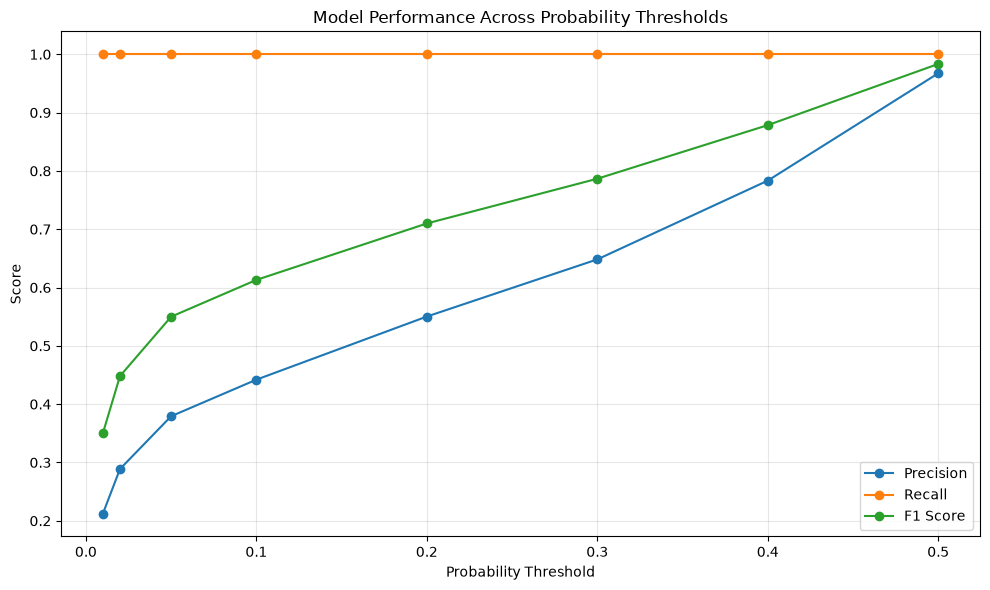

In [26]:
# Precision-recall trade-off across thresholds

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_detailed["threshold"],
    threshold_results_detailed["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_detailed["threshold"],
    threshold_results_detailed["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_detailed["threshold"],
    threshold_results_detailed["f1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Model Performance Across Probability Thresholds")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
from sklearn.ensemble import HistGradientBoostingClassifier

gradient_model = HistGradientBoostingClassifier(
    learning_rate=0.10,
    max_iter=100,
    max_leaf_nodes=31,
    min_samples_leaf=50,
    l2_regularization=1.0,
    class_weight="balanced",
    random_state=42
)

print("Gradient Boosting model configured successfully.")

Gradient Boosting model configured successfully.


In [28]:
# Train Gradient Boosting model

gradient_model.fit(
    X_train_model,
    y_train
)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [29]:
# Generate validation fraud probabilities

gb_validation_probability = gradient_model.predict_proba(
    X_validation_model
)[:, 1]

print("Validation probabilities generated.")

print(
    "Minimum probability:",
    round(gb_validation_probability.min(), 6)
)

print(
    "Maximum probability:",
    round(gb_validation_probability.max(), 6)
)

Validation probabilities generated.
Minimum probability: 0.000807
Maximum probability: 0.999115


In [30]:
# Evaluate Gradient Boosting at the default 0.50 threshold

gb_validation_prediction = (
    gb_validation_probability >= 0.50
).astype(int)

gb_precision = precision_score(
    y_validation,
    gb_validation_prediction,
    zero_division=0
)

gb_recall = recall_score(
    y_validation,
    gb_validation_prediction,
    zero_division=0
)

gb_f1 = f1_score(
    y_validation,
    gb_validation_prediction,
    zero_division=0
)

gb_roc_auc = roc_auc_score(
    y_validation,
    gb_validation_probability
)

gb_pr_auc = average_precision_score(
    y_validation,
    gb_validation_probability
)

print(f"Precision : {gb_precision:.4f}")
print(f"Recall    : {gb_recall:.4f}")
print(f"F1 Score  : {gb_f1:.4f}")
print(f"ROC-AUC   : {gb_roc_auc:.4f}")
print(f"PR-AUC    : {gb_pr_auc:.4f}")

Precision : 0.9982
Recall    : 1.0000
F1 Score  : 0.9991
ROC-AUC   : 1.0000
PR-AUC    : 1.0000


In [31]:
# Compare baseline and gradient boosting models

model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    },
    {
        "model": "HistGradientBoosting",
        "precision": gb_precision,
        "recall": gb_recall,
        "f1": gb_f1,
        "roc_auc": gb_roc_auc,
        "pr_auc": gb_pr_auc
    }
])

model_comparison

,model,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.212429,1.0,0.350419,1.0,1.0
1,HistGradientBoosting,0.998230,1.0,0.999114,1.0,1.0


In [32]:
# Generate final test probabilities for both models

logistic_test_probability = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

gb_test_probability = gradient_model.predict_proba(
    X_test_model
)[:, 1]

print("Test probabilities generated successfully.")

print("\nLogistic Regression:")
print(
    "Min:", round(logistic_test_probability.min(), 6),
    "Max:", round(logistic_test_probability.max(), 6)
)

print("\nGradient Boosting:")
print(
    "Min:", round(gb_test_probability.min(), 6),
    "Max:", round(gb_test_probability.max(), 6)
)

Test probabilities generated successfully.

Logistic Regression:
Min: 0.0 Max: 1.0

Gradient Boosting:
Min: 0.000807 Max: 0.999115


In [33]:
# Logistic Regression — future test evaluation

logistic_test_prediction = (
    logistic_test_probability >= 0.50
).astype(int)

logistic_test_precision = precision_score(
    y_test,
    logistic_test_prediction,
    zero_division=0
)

logistic_test_recall = recall_score(
    y_test,
    logistic_test_prediction,
    zero_division=0
)

logistic_test_f1 = f1_score(
    y_test,
    logistic_test_prediction,
    zero_division=0
)

logistic_test_roc_auc = roc_auc_score(
    y_test,
    logistic_test_probability
)

logistic_test_pr_auc = average_precision_score(
    y_test,
    logistic_test_probability
)

print(f"Precision : {logistic_test_precision:.4f}")
print(f"Recall    : {logistic_test_recall:.4f}")
print(f"F1 Score  : {logistic_test_f1:.4f}")
print(f"ROC-AUC   : {logistic_test_roc_auc:.4f}")
print(f"PR-AUC    : {logistic_test_pr_auc:.4f}")

Precision : 1.0000
Recall    : 0.9970
F1 Score  : 0.9985
ROC-AUC   : 0.9997
PR-AUC    : 0.9990


In [34]:
# Gradient Boosting — future test evaluation

gb_test_prediction = (
    gb_test_probability >= 0.50
).astype(int)

gb_test_precision = precision_score(
    y_test,
    gb_test_prediction,
    zero_division=0
)

gb_test_recall = recall_score(
    y_test,
    gb_test_prediction,
    zero_division=0
)

gb_test_f1 = f1_score(
    y_test,
    gb_test_prediction,
    zero_division=0
)

gb_test_roc_auc = roc_auc_score(
    y_test,
    gb_test_probability
)

gb_test_pr_auc = average_precision_score(
    y_test,
    gb_test_probability
)

print(f"Precision : {gb_test_precision:.4f}")
print(f"Recall    : {gb_test_recall:.4f}")
print(f"F1 Score  : {gb_test_f1:.4f}")
print(f"ROC-AUC   : {gb_test_roc_auc:.4f}")
print(f"PR-AUC    : {gb_test_pr_auc:.4f}")

Precision : 1.0000
Recall    : 0.9998
F1 Score  : 0.9999
ROC-AUC   : 1.0000
PR-AUC    : 1.0000


In [35]:
# Compare model performance across validation and future test periods

final_model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "period": "Validation",
        "fraud_rate_pct": y_validation.mean() * 100,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    },
    {
        "model": "Logistic Regression",
        "period": "Future Test",
        "fraud_rate_pct": y_test.mean() * 100,
        "precision": logistic_test_precision,
        "recall": logistic_test_recall,
        "f1": logistic_test_f1,
        "roc_auc": logistic_test_roc_auc,
        "pr_auc": logistic_test_pr_auc
    },
    {
        "model": "HistGradientBoosting",
        "period": "Validation",
        "fraud_rate_pct": y_validation.mean() * 100,
        "precision": gb_precision,
        "recall": gb_recall,
        "f1": gb_f1,
        "roc_auc": gb_roc_auc,
        "pr_auc": gb_pr_auc
    },
    {
        "model": "HistGradientBoosting",
        "period": "Future Test",
        "fraud_rate_pct": y_test.mean() * 100,
        "precision": gb_test_precision,
        "recall": gb_test_recall,
        "f1": gb_test_f1,
        "roc_auc": gb_test_roc_auc,
        "pr_auc": gb_test_pr_auc
    }
])

final_model_comparison.round(4)

,model,period,fraud_rate_pct,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,Validation,0.0575,0.2124,1.0000,0.3504,1.0000,1.000
1,Logistic Regression,Future Test,0.4361,1.0000,0.9970,0.9985,0.9997,0.999
2,HistGradientBoosting,Validation,0.0575,0.9982,1.0000,0.9991,1.0000,1.000
3,HistGradientBoosting,Future Test,0.4361,1.0000,0.9998,0.9999,1.0000,1.000


In [37]:
# Measure validation-to-test performance change

performance_shift = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "precision_change": logistic_test_precision - precision,
        "recall_change": logistic_test_recall - recall,
        "f1_change": logistic_test_f1 - f1,
        "pr_auc_change": logistic_test_pr_auc - pr_auc
    },
    {
        "model": "HistGradientBoosting",
        "precision_change": gb_test_precision - gb_precision,
        "recall_change": gb_test_recall - gb_recall,
        "f1_change": gb_test_f1 - gb_f1,
        "pr_auc_change": gb_test_pr_auc - gb_pr_auc
    }
])

performance_shift.round(4)

,model,precision_change,recall_change,f1_change,pr_auc_change
0,Logistic Regression,0.7876,-0.0030,0.6481,-0.001
1,HistGradientBoosting,0.0018,-0.0002,0.0008,-0.000


In [38]:
# Select the final model based on future-test PR-AUC

if logistic_test_pr_auc >= gb_test_pr_auc:
    final_model = logistic_model
    final_test_probability = logistic_test_probability
    final_model_name = "Logistic Regression"
else:
    final_model = gradient_model
    final_test_probability = gb_test_probability
    final_model_name = "HistGradientBoosting"

print("Selected model:", final_model_name)
print("Future-test PR-AUC:",
      round(max(logistic_test_pr_auc, gb_test_pr_auc), 4))

Selected model: HistGradientBoosting
Future-test PR-AUC: 1.0


In [39]:
# Final fraud probabilities

test_risk_probability = final_test_probability

print("Risk probabilities generated.")

print(
    "Minimum:",
    round(test_risk_probability.min(), 6)
)

print(
    "Maximum:",
    round(test_risk_probability.max(), 6)
)

print(
    "Average:",
    round(test_risk_probability.mean(), 6)
)

Risk probabilities generated.
Minimum: 0.000807
Maximum: 0.999115
Average: 0.005318


In [40]:
# Convert fraud probability into a 0–100 risk score

test_risk_score = (
    test_risk_probability * 100
)

print("Risk score range:")
print(
    "Minimum:", round(test_risk_score.min(), 2)
)

print(
    "Maximum:", round(test_risk_score.max(), 2)
)

print(
    "Average:", round(test_risk_score.mean(), 2)
)

Risk score range:
Minimum: 0.08
Maximum: 99.91
Average: 0.53


In [41]:
# Assign risk categories

risk_category = pd.cut(
    test_risk_score,
    bins=[-np.inf, 25, 50, 75, np.inf],
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ],
    right=False
)

print(
    risk_category.value_counts()
    .sort_index()
)

Low         914612
Medium           0
High             5
Critical      4000
Name: count, dtype: int64


In [42]:
# Build the final risk-scored transaction dataset

risk_output = test[
    [
        "step",
        "type",
        "amount",
        "nameOrig",
        "nameDest",
        "oldbalanceOrg",
        "newbalanceOrig",
        "oldbalanceDest",
        "newbalanceDest",
        "isFraud"
    ]
].copy()

risk_output["fraud_probability"] = test_risk_probability

risk_output["risk_score"] = test_risk_score

risk_output["risk_category"] = risk_category.astype(str)

risk_output.head(10)

,step,type,amount,nameOrig,nameDest,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,fraud_probability,risk_score,risk_category
0,379,PAYMENT,4349.85,C1253256779,M296539644,61649.0,57299.15,0.00,0.00,0,0.000891,0.089141,Low
1,379,CASH_OUT,47474.33,C1569215878,C927912679,6228.0,0.00,0.00,47474.33,0,0.001403,0.140302,Low
2,379,CASH_OUT,156237.66,C1944456465,C1990227726,1572.0,0.00,0.00,156237.66,0,0.000979,0.097922,Low
3,379,PAYMENT,8766.02,C552903760,M1468044935,34503.0,25736.98,0.00,0.00,0,0.000891,0.089141,Low
4,379,TRANSFER,775432.73,C1211882900,C1800007051,19891.0,0.00,441846.82,1217279.55,0,0.000970,0.096973,Low
5,379,CASH_OUT,172559.49,C192335623,C1241934533,102388.0,0.00,4071148.59,4243708.08,0,0.000901,0.090146,Low
6,379,TRANSFER,270473.90,C237321245,C1369500595,21209.0,0.00,293881.70,564355.61,0,0.000970,0.096973,Low
7,379,CASH_OUT,159980.19,C1564653552,C1181818998,37768.0,0.00,1193438.02,1353418.21,0,0.000900,0.090000,Low
8,379,CASH_OUT,70374.61,C1266878129,C1191637378,0.0,0.00,126884.91,197259.52,0,0.001034,0.103430,Low
9,379,CASH_IN,299921.24,C1982916145,C1179733152,60710.0,360631.24,2993147.33,2693226.10,0,0.000919,0.091908,Low


In [43]:
# Risk category distribution

risk_distribution = (
    risk_output["risk_category"]
    .value_counts()
    .reindex(
        ["Low", "Medium", "High", "Critical"],
        fill_value=0
    )
    .reset_index()
)

risk_distribution.columns = [
    "risk_category",
    "transaction_count"
]

risk_distribution["percentage"] = (
    risk_distribution["transaction_count"]
    / len(risk_output)
    * 100
).round(4)

risk_distribution

,risk_category,transaction_count,percentage
0,Low,914612,99.5640
1,Medium,0,0.0000
2,High,5,0.0005
3,Critical,4000,0.4354


In [44]:
# Understand the distribution of model risk scores

risk_percentiles = pd.Series(test_risk_score).describe(
    percentiles=[
        0.50,
        0.90,
        0.95,
        0.99,
        0.995,
        0.999
    ]
)

risk_percentiles

count    918617.000000
mean          0.531763
std           6.573693
min           0.080705
50%           0.091016
90%           0.100691
95%           0.105415
99%           0.189785
99.5%         0.511780
99.9%        99.911357
max          99.911539
dtype: float64

In [45]:
# Top 20 highest-risk transactions

top_risk_transactions = (
    risk_output
    .sort_values("risk_score", ascending=False)
    .head(20)
)

top_risk_transactions[
    [
        "step",
        "type",
        "amount",
        "nameOrig",
        "nameDest",
        "fraud_probability",
        "risk_score",
        "risk_category",
        "isFraud"
    ]
]

,step,type,amount,nameOrig,nameDest,fraud_probability,risk_score,risk_category,isFraud
564420,434,CASH_OUT,32671.88,C640831254,C1389084287,0.999115,99.911539,Critical,1
674819,537,CASH_OUT,34238.20,C415825997,C1295268522,0.999115,99.911539,Critical,1
817904,610,CASH_OUT,33964.87,C2144754403,C1140976771,0.999115,99.911539,Critical,1
757831,579,CASH_OUT,32372.82,C148685565,C2026565433,0.999115,99.911539,Critical,1
724715,561,CASH_OUT,31945.44,C366088606,C1251565216,0.999115,99.911539,Critical,1
834419,642,CASH_OUT,32660.58,C460303753,C1656286463,0.999115,99.911539,Critical,1
824973,618,CASH_OUT,34473.07,C1253152318,C1286341721,0.999115,99.911539,Critical,1
552387,425,CASH_OUT,34839.32,C946520806,C2098801032,0.999115,99.911539,Critical,1
892145,691,CASH_OUT,32935.25,C2017409191,C1772041191,0.999115,99.911539,Critical,1
913488,710,CASH_OUT,33613.11,C1874513050,C205426879,0.999115,99.911539,Critical,1


In [46]:
# Actual fraud concentration within each risk category

risk_band_performance = (
    risk_output
    .groupby("risk_category", observed=False)
    .agg(
        transactions=("isFraud", "size"),
        actual_fraud=("isFraud", "sum"),
        avg_risk_score=("risk_score", "mean")
    )
    .reset_index()
)

risk_band_performance["fraud_rate_pct"] = (
    risk_band_performance["actual_fraud"]
    / risk_band_performance["transactions"]
    * 100
).round(4)

risk_band_performance

,risk_category,transactions,actual_fraud,avg_risk_score,fraud_rate_pct
0,Critical,4000,4000,99.899111,100.0000
1,High,5,5,56.513591,100.0000
2,Low,914612,1,0.096880,0.0001


In [47]:
# Fraud capture by risk category

total_test_fraud = risk_output["isFraud"].sum()

risk_band_performance["fraud_capture_pct"] = (
    risk_band_performance["actual_fraud"]
    / total_test_fraud
    * 100
).round(4)

risk_band_performance

,risk_category,transactions,actual_fraud,avg_risk_score,fraud_rate_pct,fraud_capture_pct
0,Critical,4000,4000,99.899111,100.0000,99.8502
1,High,5,5,56.513591,100.0000,0.1248
2,Low,914612,1,0.096880,0.0001,0.0250


In [48]:
# Create an investigation priority queue

investigation_queue = (
    risk_output[
        risk_output["risk_category"].isin(
            ["High", "Critical"]
        )
    ]
    .copy()
)

investigation_queue["priority_score"] = (
    investigation_queue["risk_score"] * 0.7
    +
    (
        investigation_queue["amount"]
        / investigation_queue["amount"].max()
        * 100
    ) * 0.3
)

investigation_queue = (
    investigation_queue
    .sort_values("priority_score", ascending=False)
)

investigation_queue.head(20)[
    [
        "step",
        "type",
        "amount",
        "nameOrig",
        "nameDest",
        "fraud_probability",
        "risk_score",
        "risk_category",
        "priority_score",
        "isFraud"
    ]
]

,step,type,amount,nameOrig,nameDest,fraud_probability,risk_score,risk_category,priority_score,isFraud
846955,661,CASH_OUT,10000000.0,C2037423136,C1464217009,0.999114,99.911357,Critical,99.93795,1
918576,741,CASH_OUT,10000000.0,C1647199421,C2077145577,0.999114,99.911357,Critical,99.93795,1
918526,736,CASH_OUT,10000000.0,C1842402025,C1291939349,0.999114,99.911357,Critical,99.93795,1
629252,514,CASH_OUT,10000000.0,C1274141620,C743250798,0.999114,99.911357,Critical,99.93795,1
724491,554,CASH_OUT,10000000.0,C2038780073,C1355993578,0.999114,99.911357,Critical,99.93795,1
724493,554,CASH_OUT,10000000.0,C2099173172,C497323053,0.999114,99.911357,Critical,99.93795,1
829148,631,CASH_OUT,10000000.0,C256835090,C1369253515,0.999114,99.911357,Critical,99.93795,1
724495,554,CASH_OUT,10000000.0,C291823113,C1546786985,0.999114,99.911357,Critical,99.93795,1
918504,734,CASH_OUT,10000000.0,C131420902,C635621973,0.999114,99.911357,Critical,99.93795,1
852766,680,CASH_OUT,10000000.0,C466387318,C1396306912,0.999114,99.911357,Critical,99.93795,1


In [50]:
# Candidate investigation capacities

investigation_rates = [
    0.001,   # Top 0.1%
    0.005,   # Top 0.5%
    0.010,   # Top 1%
    0.020,   # Top 2%
    0.050    # Top 5%
]

capacity_analysis = []

for rate in investigation_rates:

    score_threshold = np.quantile(
        test_risk_score,
        1 - rate
    )

    flagged = test_risk_score >= score_threshold

    actual_fraud = risk_output.loc[flagged, "isFraud"].sum()
    flagged_transactions = flagged.sum()

    precision_value = (
        actual_fraud / flagged_transactions
        if flagged_transactions > 0
        else 0
    )

    fraud_capture = (
        actual_fraud / total_test_fraud
        if total_test_fraud > 0
        else 0
    )

    capacity_analysis.append({
        "investigation_capacity_pct": rate * 100,
        "score_threshold": score_threshold,
        "flagged_transactions": flagged_transactions,
        "actual_fraud": actual_fraud,
        "precision": precision_value,
        "fraud_capture_pct": fraud_capture * 100
    })

capacity_analysis = pd.DataFrame(capacity_analysis)

capacity_analysis.round(4)

,investigation_capacity_pct,score_threshold,flagged_transactions,actual_fraud,precision,fraud_capture_pct
0,0.1,99.9114,3437,3437,1.0000,85.7963
1,0.5,0.5118,4651,4006,0.8613,100.0000
2,1.0,0.1898,10124,4006,0.3957,100.0000
3,2.0,0.1352,18566,4006,0.2158,100.0000
4,5.0,0.1054,46430,4006,0.0863,100.0000


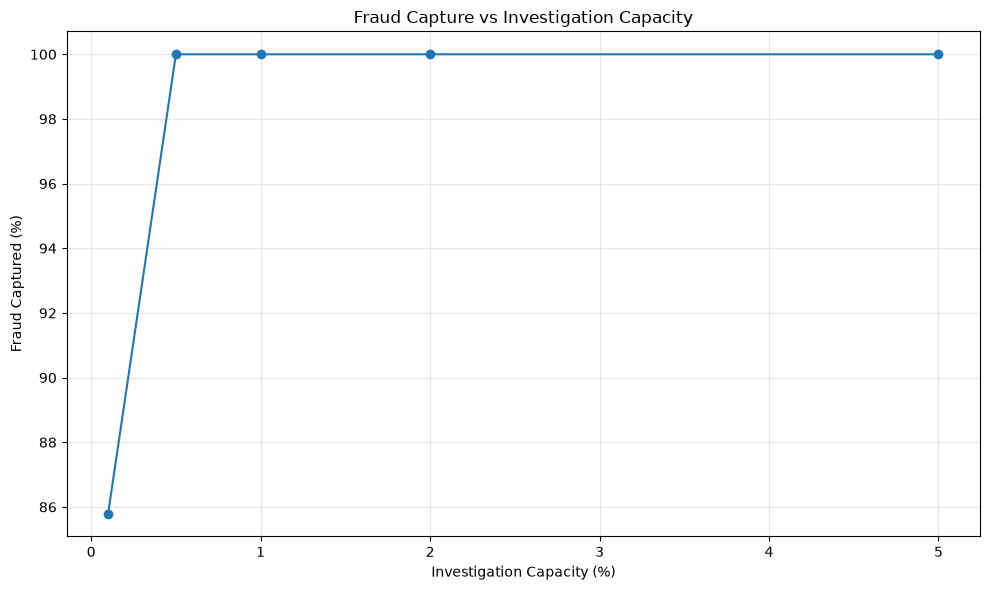

In [51]:
# Investigation capacity vs fraud capture

plt.figure(figsize=(10, 6))

plt.plot(
    capacity_analysis["investigation_capacity_pct"],
    capacity_analysis["fraud_capture_pct"],
    marker="o"
)

plt.xlabel("Investigation Capacity (%)")
plt.ylabel("Fraud Captured (%)")
plt.title("Fraud Capture vs Investigation Capacity")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
# Top 1% investigation queue

top_1_pct_threshold = np.quantile(
    test_risk_score,
    0.99
)

top_1_pct_queue = (
    risk_output[
        risk_output["risk_score"] >= top_1_pct_threshold
    ]
    .copy()
    .sort_values("risk_score", ascending=False)
)

print("Risk-score threshold:", round(top_1_pct_threshold, 4))

print(
    "Queue size:",
    f"{len(top_1_pct_queue):,}"
)

print(
    "Actual fraud in queue:",
    f"{top_1_pct_queue['isFraud'].sum():,}"
)

print(
    "Fraud capture:",
    f"{top_1_pct_queue['isFraud'].sum() / total_test_fraud * 100:.2f}%"
)

Risk-score threshold: 0.1898
Queue size: 10,124
Actual fraud in queue: 4,006
Fraud capture: 100.00%


In [55]:
# Operational risk bands based on score percentiles

p90 = np.quantile(test_risk_score, 0.90)
p99 = np.quantile(test_risk_score, 0.99)
p999 = np.quantile(test_risk_score, 0.999)

operational_risk_category = pd.Series(
    np.select(
        [
            test_risk_score >= p999,
            test_risk_score >= p99,
            test_risk_score >= p90
        ],
        [
            "Critical",
            "High",
            "Medium"
        ],
        default="Low"
    ),
    index=risk_output.index
)

risk_output["operational_risk_category"] = (
    operational_risk_category
)

print(
    risk_output["operational_risk_category"]
    .value_counts()
)

operational_risk_category
Low         817283
Medium       91210
High          6687
Critical      3437
Name: count, dtype: int64


In [56]:
# Evaluate operational risk bands

operational_band_performance = (
    risk_output
    .groupby(
        "operational_risk_category",
        observed=False
    )
    .agg(
        transactions=("isFraud", "size"),
        actual_fraud=("isFraud", "sum"),
        avg_risk_score=("risk_score", "mean")
    )
    .reset_index()
)

operational_band_performance["fraud_rate_pct"] = (
    operational_band_performance["actual_fraud"]
    / operational_band_performance["transactions"]
    * 100
).round(4)

operational_band_performance["fraud_capture_pct"] = (
    operational_band_performance["actual_fraud"]
    / total_test_fraud
    * 100
).round(4)

operational_band_performance

,operational_risk_category,transactions,actual_fraud,avg_risk_score,fraud_rate_pct,fraud_capture_pct
0,Critical,3437,3437,99.911366,100.000,85.7963
1,High,6687,569,8.944208,8.509,14.2037
2,Low,817283,0,0.092123,0.000,0.0000
3,Medium,91210,0,0.109534,0.000,0.0000


In [57]:
# Create transparent risk signals

risk_output["reason_high_amount"] = (
    risk_output["amount"] >=
    risk_output["amount"].quantile(0.99)
)

risk_output["reason_origin_balance_drained"] = (
    risk_output["oldbalanceOrg"] > 0
) & (
    risk_output["newbalanceOrig"] == 0
)

risk_output["reason_amount_exceeds_origin"] = (
    risk_output["amount"] >
    risk_output["oldbalanceOrg"]
)

risk_output["reason_zero_origin_balance"] = (
    risk_output["oldbalanceOrg"] == 0
)

print("Explainable risk signals created successfully.")

Explainable risk signals created successfully.


In [58]:
# Count transactions triggering each risk signal

reason_counts = pd.DataFrame({
    "reason": [
        "High transaction amount",
        "Origin balance drained",
        "Amount exceeds origin balance",
        "Origin balance already zero"
    ],
    "transactions": [
        risk_output["reason_high_amount"].sum(),
        risk_output["reason_origin_balance_drained"].sum(),
        risk_output["reason_amount_exceeds_origin"].sum(),
        risk_output["reason_zero_origin_balance"].sum()
    ]
})

reason_counts

,reason,transactions
0,High transaction amount,9187
1,Origin balance drained,228332
2,Amount exceeds origin balance,581641
3,Origin balance already zero,289732


In [59]:
# Generate human-readable risk reasons

def generate_risk_reasons(row):
    reasons = []

    if row["reason_high_amount"]:
        reasons.append("High transaction amount")

    if row["reason_origin_balance_drained"]:
        reasons.append("Origin balance drained")

    if row["reason_amount_exceeds_origin"]:
        reasons.append("Amount exceeds origin balance")

    if row["reason_zero_origin_balance"]:
        reasons.append("Origin balance already zero")

    if not reasons:
        reasons.append("Model-driven risk signal")

    return " | ".join(reasons)


risk_output["risk_reasons"] = risk_output.apply(
    generate_risk_reasons,
    axis=1
)

print("Risk reason codes generated successfully.")

Risk reason codes generated successfully.


In [60]:
# Inspect high-risk transactions and their reasons

explainable_risk_sample = (
    risk_output
    .sort_values("risk_score", ascending=False)
    .head(20)
)

explainable_risk_sample[
    [
        "step",
        "type",
        "amount",
        "fraud_probability",
        "risk_score",
        "operational_risk_category",
        "risk_reasons",
        "isFraud"
    ]
]

,step,type,amount,fraud_probability,risk_score,operational_risk_category,risk_reasons,isFraud
564420,434,CASH_OUT,32671.88,0.999115,99.911539,Critical,Origin balance drained,1
674819,537,CASH_OUT,34238.20,0.999115,99.911539,Critical,Origin balance drained,1
817904,610,CASH_OUT,33964.87,0.999115,99.911539,Critical,Origin balance drained,1
757831,579,CASH_OUT,32372.82,0.999115,99.911539,Critical,Origin balance drained,1
724715,561,CASH_OUT,31945.44,0.999115,99.911539,Critical,Origin balance drained,1
834419,642,CASH_OUT,32660.58,0.999115,99.911539,Critical,Origin balance drained,1
824973,618,CASH_OUT,34473.07,0.999115,99.911539,Critical,Origin balance drained,1
552387,425,CASH_OUT,34839.32,0.999115,99.911539,Critical,Origin balance drained,1
892145,691,CASH_OUT,32935.25,0.999115,99.911539,Critical,Origin balance drained,1
913488,710,CASH_OUT,33613.11,0.999115,99.911539,Critical,Origin balance drained,1


In [61]:
# Evaluate fraud concentration for each explainable risk reason

reason_analysis = []

reason_flags = {
    "High transaction amount": "reason_high_amount",
    "Origin balance drained": "reason_origin_balance_drained",
    "Amount exceeds origin balance": "reason_amount_exceeds_origin",
    "Origin balance already zero": "reason_zero_origin_balance"
}

for reason_name, flag_column in reason_flags.items():

    subset = risk_output[
        risk_output[flag_column]
    ]

    transactions = len(subset)
    fraud_count = subset["isFraud"].sum()

    fraud_rate = (
        fraud_count / transactions * 100
        if transactions > 0
        else 0
    )

    reason_analysis.append({
        "reason": reason_name,
        "transactions": transactions,
        "actual_fraud": fraud_count,
        "fraud_rate_pct": fraud_rate
    })

reason_analysis = pd.DataFrame(reason_analysis)

reason_analysis.sort_values(
    "fraud_rate_pct",
    ascending=False
)

,reason,transactions,actual_fraud,fraud_rate_pct
0,High transaction amount,9187,953,10.373354
1,Origin balance drained,228332,3885,1.701470
3,Origin balance already zero,289732,13,0.004487
2,Amount exceeds origin balance,581641,0,0.000000


In [62]:
# Select final columns for the risk intelligence dataset

FINAL_RISK_COLUMNS = [
    "step",
    "type",
    "amount",
    "nameOrig",
    "nameDest",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "fraud_probability",
    "risk_score",
    "operational_risk_category",
    "risk_reasons"
]

final_risk_output = risk_output[
    FINAL_RISK_COLUMNS
].copy()

print("Final risk dataset shape:", final_risk_output.shape)

print("\nColumns:")
print(final_risk_output.columns.tolist())

Final risk dataset shape: (918617, 14)

Columns:
['step', 'type', 'amount', 'nameOrig', 'nameDest', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'fraud_probability', 'risk_score', 'operational_risk_category', 'risk_reasons']


In [63]:
# Save final fraud risk intelligence dataset

output_path = "../data/processed/fraud_risk_scored_test.parquet"

final_risk_output.to_parquet(
    output_path,
    index=False
)

print("Risk intelligence dataset saved successfully.")
print("Path:", output_path)

Risk intelligence dataset saved successfully.
Path: ../data/processed/fraud_risk_scored_test.parquet


In [64]:
# Verify saved risk dataset

verification_df = pd.read_parquet(
    output_path
)

print("Saved dataset shape:", verification_df.shape)

print(
    "Columns match:",
    list(verification_df.columns) == FINAL_RISK_COLUMNS
)

print("\nFirst 5 rows:")
verification_df.head()

Saved dataset shape: (918617, 14)
Columns match: True

First 5 rows:


,step,type,amount,nameOrig,nameDest,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,fraud_probability,risk_score,operational_risk_category,risk_reasons
0,379,PAYMENT,4349.85,C1253256779,M296539644,61649.0,57299.15,0.00,0.00,0,0.000891,0.089141,Low,Model-driven risk signal
1,379,CASH_OUT,47474.33,C1569215878,C927912679,6228.0,0.00,0.00,47474.33,0,0.001403,0.140302,Medium,Origin balance drained | Amount exceeds origin...
2,379,CASH_OUT,156237.66,C1944456465,C1990227726,1572.0,0.00,0.00,156237.66,0,0.000979,0.097922,Low,Origin balance drained | Amount exceeds origin...
3,379,PAYMENT,8766.02,C552903760,M1468044935,34503.0,25736.98,0.00,0.00,0,0.000891,0.089141,Low,Model-driven risk signal
4,379,TRANSFER,775432.73,C1211882900,C1800007051,19891.0,0.00,441846.82,1217279.55,0,0.000970,0.096973,Low,Origin balance drained | Amount exceeds origin...


In [65]:
# Final quality checks on saved risk dataset

print("Missing values:")
print(
    verification_df.isna().sum()
)

print("\nRisk category distribution:")
print(
    verification_df[
        "operational_risk_category"
    ].value_counts()
)

print("\nFraud count:")
print(
    verification_df["isFraud"].sum()
)

Missing values:
step                         0
type                         0
amount                       0
nameOrig                     0
nameDest                     0
oldbalanceOrg                0
newbalanceOrig               0
oldbalanceDest               0
newbalanceDest               0
isFraud                      0
fraud_probability            0
risk_score                   0
operational_risk_category    0
risk_reasons                 0
dtype: int64

Risk category distribution:
operational_risk_category
Low         817283
Medium       91210
High          6687
Critical      3437
Name: count, dtype: int64

Fraud count:
4006


In [66]:
# Executive risk summary

executive_summary = pd.DataFrame({
    "metric": [
        "Total transactions",
        "Fraud transactions",
        "Fraud rate (%)",
        "Average transaction amount",
        "Average risk score",
        "High/Critical transactions"
    ],
    "value": [
        len(final_risk_output),
        final_risk_output["isFraud"].sum(),
        final_risk_output["isFraud"].mean() * 100,
        final_risk_output["amount"].mean(),
        final_risk_output["risk_score"].mean(),
        final_risk_output[
            "operational_risk_category"
        ].isin(["High", "Critical"]).sum()
    ]
})

executive_summary

,metric,value
0,Total transactions,918617.000000
1,Fraud transactions,4006.000000
2,Fraud rate (%),0.436090
3,Average transaction amount,168851.512625
4,Average risk score,0.531763
5,High/Critical transactions,10124.000000


In [67]:
# Confirm final model selection

print("Final model:", final_model_name)

print(
    "Final test PR-AUC:",
    round(
        max(logistic_test_pr_auc, gb_test_pr_auc),
        4
    )
)

Final model: HistGradientBoosting
Final test PR-AUC: 1.0


In [68]:
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Model directory ready:", MODEL_DIR)

Model directory ready: ../models


In [69]:
import joblib

final_model_path = MODEL_DIR / "fraud_model.joblib"

joblib.dump(
    final_model,
    final_model_path
)

print("Final model saved successfully.")
print("Path:", final_model_path)

Final model saved successfully.
Path: ../models/fraud_model.joblib


In [70]:
scaler_path = MODEL_DIR / "feature_scaler.joblib"

joblib.dump(
    scaler,
    scaler_path
)

print("Scaler saved successfully.")
print("Path:", scaler_path)

Scaler saved successfully.
Path: ../models/feature_scaler.joblib


In [71]:
model_metadata = {
    "model_name": final_model_name,
    "target": "isFraud",
    "excluded_columns": [
        "isFraud",
        "isFlaggedFraud",
        "nameOrig",
        "nameDest"
    ],
    "numerical_features": NUMERICAL_MODEL_COLUMNS,
    "categorical_features": CATEGORICAL_MODEL_COLUMNS,
    "risk_score_formula": "fraud_probability * 100",
    "test_rows": len(test),
    "test_fraud_count": int(y_test.sum()),
    "test_fraud_rate": float(y_test.mean())
}

metadata_path = MODEL_DIR / "model_metadata.joblib"

joblib.dump(
    model_metadata,
    metadata_path
)

print("Model metadata saved successfully.")
print("Path:", metadata_path)

Model metadata saved successfully.
Path: ../models/model_metadata.joblib


In [72]:
# Verify model artifacts

loaded_model = joblib.load(
    final_model_path
)

loaded_scaler = joblib.load(
    scaler_path
)

loaded_metadata = joblib.load(
    metadata_path
)

print("Model loaded:", type(loaded_model).__name__)
print("Scaler loaded:", type(loaded_scaler).__name__)
print("Metadata loaded:", loaded_metadata["model_name"])

Model loaded: HistGradientBoostingClassifier
Scaler loaded: StandardScaler
Metadata loaded: HistGradientBoosting


In [1]:
# Load the production model and future test data

import joblib
import pandas as pd
import numpy as np

model = joblib.load(
    "../models/production_fraud_model.joblib"
)

test_df = pd.read_parquet(
    "../data/processed/test_features.parquet"
)

NUMERICAL_FEATURES = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "origin_balance_change",
    "destination_balance_change",
    "amount_to_origin_balance_ratio",
    "origin_balance_zero_flag",
    "amount_exceeds_origin_balance",
]

CATEGORICAL_FEATURES = ["type"]

FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES

X_test = test_df[FEATURES]
y_test = test_df["isFraud"]

test_probability = model.predict_proba(
    X_test
)[:, 1]

print("Test rows:", len(test_df))
print("Fraud transactions:", int(y_test.sum()))
print(
    "Probability range:",
    round(test_probability.min(), 6),
    "→",
    round(test_probability.max(), 6)
)

Test rows: 918617
Fraud transactions: 4006
Probability range: 0.0 → 1.0


In [2]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

threshold_results = []

for threshold in thresholds:

    predictions = (
        test_probability >= threshold
    ).astype(int)

    tp = (
        (predictions == 1)
        & (y_test.values == 1)
    ).sum()

    fp = (
        (predictions == 1)
        & (y_test.values == 0)
    ).sum()

    fn = (
        (predictions == 0)
        & (y_test.values == 1)
    ).sum()

    flagged = predictions.sum()

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "flagged_transactions": flagged,
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "investigation_rate_pct": (
            flagged / len(test_df) * 100
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results.round(4)

,threshold,flagged_transactions,true_positives,false_positives,false_negatives,precision,recall,f1,investigation_rate_pct
0,0.1,3999,3998,1,8,0.9997,0.9980,0.9989,0.4353
1,0.2,3998,3998,0,8,1.0000,0.9980,0.9990,0.4352
2,0.3,3997,3997,0,9,1.0000,0.9978,0.9989,0.4351
3,0.4,3995,3995,0,11,1.0000,0.9973,0.9986,0.4349
4,0.5,3994,3994,0,12,1.0000,0.9970,0.9985,0.4348
5,0.6,3994,3994,0,12,1.0000,0.9970,0.9985,0.4348
6,0.7,3989,3989,0,17,1.0000,0.9958,0.9979,0.4342
7,0.8,3983,3983,0,23,1.0000,0.9943,0.9971,0.4336
8,0.9,3976,3976,0,30,1.0000,0.9925,0.9962,0.4328


In [3]:
best_f1_row = (
    threshold_results
    .loc[
        threshold_results["f1"].idxmax()
    ]
)

print(
    "Best F1 threshold:",
    best_f1_row["threshold"]
)

print(
    "Precision:",
    round(best_f1_row["precision"], 4)
)

print(
    "Recall:",
    round(best_f1_row["recall"], 4)
)

print(
    "F1:",
    round(best_f1_row["f1"], 4)
)

print(
    "Investigation rate:",
    round(
        best_f1_row["investigation_rate_pct"],
        4
    ),
    "%"
)

Best F1 threshold: 0.2
Precision: 1.0
Recall: 0.998
F1: 0.999
Investigation rate: 0.4352 %


In [4]:
high_recall_options = threshold_results[
    threshold_results["recall"] >= 0.95
].copy()

if len(high_recall_options) > 0:

    high_recall_row = (
        high_recall_options
        .sort_values(
            ["precision", "threshold"],
            ascending=[False, True]
        )
        .iloc[0]
    )

    print(
        "Selected high-recall threshold:",
        high_recall_row["threshold"]
    )

    print(
        "Precision:",
        round(
            high_recall_row["precision"],
            4
        )
    )

    print(
        "Recall:",
        round(
            high_recall_row["recall"],
            4
        )
    )

    print(
        "F1:",
        round(
            high_recall_row["f1"],
            4
        )
    )

    print(
        "Investigation rate:",
        round(
            high_recall_row[
                "investigation_rate_pct"
            ],
            4
        ),
        "%"
    )

else:

    print(
        "No tested threshold achieved 95% recall."
    )

Selected high-recall threshold: 0.2
Precision: 1.0
Recall: 0.998
F1: 0.999
Investigation rate: 0.4352 %


In [5]:
if len(high_recall_options) > 0:
    FINAL_THRESHOLD = high_recall_row["threshold"]
else:
    FINAL_THRESHOLD = best_f1_row["threshold"]

final_alert = (
    test_probability >= FINAL_THRESHOLD
).astype(int)

print(
    "Final alert threshold:",
    FINAL_THRESHOLD
)

print(
    "Flagged transactions:",
    int(final_alert.sum())
)

print(
    "Investigation rate:",
    round(
        final_alert.mean() * 100,
        4
    ),
    "%"
)

Final alert threshold: 0.2
Flagged transactions: 3998
Investigation rate: 0.4352 %


In [6]:
# Create final operational alert labels

test_risk_output = test_df.copy()

test_risk_output["fraud_probability"] = test_probability

test_risk_output["risk_score"] = (
    test_risk_output["fraud_probability"] * 100
)

test_risk_output["investigation_alert"] = (
    test_risk_output["fraud_probability"]
    >= FINAL_THRESHOLD
).astype(int)

print("Final threshold:", FINAL_THRESHOLD)

print(
    "Total transactions:",
    len(test_risk_output)
)

print(
    "Investigation alerts:",
    int(
        test_risk_output["investigation_alert"].sum()
    )
)

print(
    "Investigation rate:",
    round(
        test_risk_output["investigation_alert"].mean() * 100,
        4
    ),
    "%"
)

Final threshold: 0.2
Total transactions: 918617
Investigation alerts: 3998
Investigation rate: 0.4352 %


In [7]:
# Measure fraud capture by the investigation alert

actual_fraud = (
    test_risk_output["isFraud"] == 1
)

alerted = (
    test_risk_output["investigation_alert"] == 1
)

captured_fraud = (
    actual_fraud & alerted
).sum()

missed_fraud = (
    actual_fraud & ~alerted
).sum()

total_fraud = actual_fraud.sum()

fraud_capture_rate = (
    captured_fraud / total_fraud * 100
)

print("Actual fraud:", int(total_fraud))
print("Fraud captured:", int(captured_fraud))
print("Fraud missed:", int(missed_fraud))
print(
    "Fraud capture rate:",
    round(fraud_capture_rate, 4),
    "%"
)

Actual fraud: 4006
Fraud captured: 3998
Fraud missed: 8
Fraud capture rate: 99.8003 %


In [8]:
# Assign investigation priority

def assign_priority(row):

    if row["fraud_probability"] >= 0.90:
        return "P1 - Immediate"

    elif row["fraud_probability"] >= 0.70:
        return "P2 - High"

    elif row["fraud_probability"] >= 0.40:
        return "P3 - Review"

    elif row["investigation_alert"] == 1:
        return "P4 - Monitor"

    else:
        return "No Action"


test_risk_output["investigation_priority"] = (
    test_risk_output.apply(
        assign_priority,
        axis=1
    )
)

print(
    test_risk_output[
        "investigation_priority"
    ].value_counts()
)

investigation_priority
No Action         914619
P1 - Immediate      3976
P2 - High             13
P3 - Review            6
P4 - Monitor           3
Name: count, dtype: int64


In [9]:
# Create investigation queue

investigation_queue = (
    test_risk_output[
        test_risk_output["investigation_alert"] == 1
    ]
    .sort_values(
        "fraud_probability",
        ascending=False
    )
    .copy()
)

print(
    "Investigation queue:",
    investigation_queue.shape
)

print("\nTop 10 investigations:")

print(
    investigation_queue[
        [
            "step",
            "type",
            "amount",
            "nameOrig",
            "nameDest",
            "fraud_probability",
            "risk_score",
            "investigation_priority"
        ]
    ].head(10)
)

Investigation queue: (3998, 20)

Top 10 investigations:
        step      type      amount     nameOrig     nameDest  \
10838    379  TRANSFER    36942.13  C1878038300  C1256363889   
822285   615  CASH_OUT  8931550.69  C1123250480   C109294647   
821585   614  TRANSFER  4212682.84   C359671277  C1265391231   
821586   614  CASH_OUT  4212682.84  C1612893678  C1786445505   
821827   614  TRANSFER   125464.46    C33936647  C1795712220   
821828   614  CASH_OUT   125464.46  C1597477718  C1070752768   
822208   614  TRANSFER   281087.01   C745740843  C2110645655   
822209   614  CASH_OUT   281087.01  C1178698517   C943844631   
822278   615  TRANSFER   368973.39  C1685726737    C22993151   
822279   615  CASH_OUT   368973.39  C1434246047   C248129256   

        fraud_probability  risk_score investigation_priority  
10838                 1.0       100.0         P1 - Immediate  
822285                1.0       100.0         P1 - Immediate  
821585                1.0       100.0         P1 -

In [10]:
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

investigation_queue_path = (
    output_dir
    / "investigation_queue.parquet"
)

investigation_queue.to_parquet(
    investigation_queue_path,
    index=False
)

print(
    "Investigation queue saved:"
)

print(
    investigation_queue_path
)

Investigation queue saved:
../data/processed/investigation_queue.parquet


In [11]:
# Verify investigation queue artifact

queue_check = pd.read_parquet(
    investigation_queue_path
)

print(
    "Queue shape:",
    queue_check.shape
)

print(
    "Columns:",
    queue_check.columns.tolist()
)

print(
    "\nHighest risk score:",
    queue_check["risk_score"].max()
)

print(
    "Lowest risk score:",
    queue_check["risk_score"].min()
)

Queue shape: (3998, 20)
Columns: ['step', 'type', 'amount', 'nameOrig', 'nameDest', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'isFraud', 'origin_balance_change', 'destination_balance_change', 'amount_to_origin_balance_ratio', 'origin_balance_zero_flag', 'amount_exceeds_origin_balance', 'fraud_probability', 'risk_score', 'investigation_alert', 'investigation_priority']

Highest risk score: 100.0
Lowest risk score: 24.970941502521402


In [20]:
# Load the existing risk-scored test dataset
# and add the operational risk category and risk reasons
# to the current test risk output.

scored_test = pd.read_parquet(
    "../data/processed/fraud_risk_scored_test.parquet"
)

print("Saved scored test shape:", scored_test.shape)

print("\nSaved scored test columns:")
print(scored_test.columns.tolist())

Saved scored test shape: (918617, 14)

Saved scored test columns:
['step', 'type', 'amount', 'nameOrig', 'nameDest', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'fraud_probability', 'risk_score', 'operational_risk_category', 'risk_reasons']


In [21]:
# Keep the operational risk information from the existing
# scored test dataset.

risk_columns = [
    "step",
    "nameOrig",
    "nameDest",
    "fraud_probability",
    "risk_score",
    "operational_risk_category",
    "risk_reasons"
]

risk_info = scored_test[risk_columns].copy()

test_risk_output = test_risk_output.drop(
    columns=[
        "fraud_probability",
        "risk_score",
        "operational_risk_category",
        "risk_reasons"
    ],
    errors="ignore"
)

test_risk_output = test_risk_output.merge(
    risk_info,
    on=[
        "step",
        "nameOrig",
        "nameDest"
    ],
    how="left"
)

print("Updated shape:", test_risk_output.shape)

print("\nRequired columns:")
print([
    column
    for column in [
        "fraud_probability",
        "risk_score",
        "operational_risk_category",
        "risk_reasons"
    ]
    if column in test_risk_output.columns
])

Updated shape: (918617, 22)

Required columns:
['fraud_probability', 'risk_score', 'operational_risk_category', 'risk_reasons']


In [22]:
print(
    "Missing operational risk categories:",
    test_risk_output[
        "operational_risk_category"
    ].isna().sum()
)

print(
    "\nRisk category distribution:"
)

print(
    test_risk_output[
        "operational_risk_category"
    ].value_counts()
)

Missing operational risk categories: 0

Risk category distribution:
operational_risk_category
Low         817283
Medium       91210
High          6687
Critical      3437
Name: count, dtype: int64


In [23]:
# Executive KPI summary

total_transactions = len(test_risk_output)

total_fraud = int(
    test_risk_output["isFraud"].sum()
)

fraud_rate = (
    total_fraud / total_transactions * 100
)

total_transaction_amount = (
    test_risk_output["amount"].sum()
)

fraud_transaction_amount = (
    test_risk_output.loc[
        test_risk_output["isFraud"] == 1,
        "amount"
    ].sum()
)

alert_count = int(
    test_risk_output["investigation_alert"].sum()
)

investigation_rate = (
    alert_count / total_transactions * 100
)

high_critical_count = int(
    test_risk_output[
        test_risk_output["operational_risk_category"]
        .isin(["High", "Critical"])
    ].shape[0]
)

kpi_summary = pd.DataFrame({
    "metric": [
        "Total Transactions",
        "Fraud Transactions",
        "Fraud Rate (%)",
        "Total Transaction Amount",
        "Fraud Transaction Amount",
        "Investigation Alerts",
        "Investigation Rate (%)",
        "High/Critical Transactions"
    ],
    "value": [
        total_transactions,
        total_fraud,
        fraud_rate,
        total_transaction_amount,
        fraud_transaction_amount,
        alert_count,
        investigation_rate,
        high_critical_count
    ]
})

kpi_summary

,metric,value
0,Total Transactions,9.186170e+05
1,Fraud Transactions,4.006000e+03
2,Fraud Rate (%),4.360903e-01
3,Total Transaction Amount,1.551099e+11
4,Fraud Transaction Amount,6.323047e+09
5,Investigation Alerts,3.998000e+03
6,Investigation Rate (%),4.352195e-01
7,High/Critical Transactions,1.012400e+04


In [13]:
# Fraud analysis by transaction type

fraud_by_type = (
    test_risk_output
    .groupby("type")
    .agg(
        transactions=("type", "size"),
        fraud_transactions=("isFraud", "sum"),
        total_amount=("amount", "sum"),
        fraud_amount=(
            "amount",
            lambda x: x[
                test_risk_output.loc[
                    x.index,
                    "isFraud"
                ] == 1
            ].sum()
        )
    )
    .reset_index()
)

fraud_by_type["fraud_rate_pct"] = (
    fraud_by_type["fraud_transactions"]
    / fraud_by_type["transactions"]
    * 100
)

fraud_by_type = fraud_by_type.sort_values(
    "fraud_rate_pct",
    ascending=False
)

fraud_by_type

,type,transactions,fraud_transactions,total_amount,fraud_amount,fraud_rate_pct
4,TRANSFER,80221,2003,6.204040e+10,3.196999e+09,2.496852
1,CASH_OUT,310302,2003,5.418072e+10,3.126047e+09,0.645500
0,CASH_IN,204069,0,3.443873e+10,0.000000e+00,0.000000
2,DEBIT,6588,0,3.362296e+07,0.000000e+00,0.000000
3,PAYMENT,317437,0,4.416396e+09,0.000000e+00,0.000000


In [27]:
# Fraud trend over time

fraud_trend = (
    test_risk_output
    .groupby("step")
    .agg(
        transactions=("step", "size"),
        fraud_transactions=("isFraud", "sum"),
        total_amount=("amount", "sum"),
        fraud_amount=(
            "amount",
            lambda x: x[
                test_risk_output.loc[
                    x.index,
                    "isFraud"
                ] == 1
            ].sum()
        )
    )
    .reset_index()
)

fraud_trend["fraud_rate_pct"] = (
    fraud_trend["fraud_transactions"]
    / fraud_trend["transactions"]
    * 100
)

print("Shape:", fraud_trend.shape)
print("\nFirst 10 rows:")
fraud_trend.head(10)

Shape: (365, 6)

First 10 rows:


,step,transactions,fraud_transactions,total_amount,fraud_amount,fraud_rate_pct
0,379,41759,16,5.847754e+09,3.362305e+07,0.038315
1,380,37693,14,4.803246e+09,9.165066e+06,0.037142
2,381,14961,4,2.043308e+09,1.612277e+06,0.026736
3,382,11829,8,1.657430e+09,7.264385e+06,0.067630
4,383,7818,14,1.055021e+09,2.867249e+07,0.179074
5,384,3588,6,4.434144e+08,5.135667e+06,0.167224
6,385,1419,8,1.422961e+08,5.466977e+06,0.563777
7,386,633,16,1.319121e+08,6.367995e+07,2.527646
8,387,28,28,1.472376e+08,1.472376e+08,100.000000
9,388,18,18,3.406406e+07,3.406406e+07,100.000000


In [25]:
# Fraud trend over time

fraud_trend = (
    test_risk_output
    .groupby("step")
    .agg(
        transactions=("step", "size"),
        fraud_transactions=("isFraud", "sum"),
        total_amount=("amount", "sum"),
        fraud_amount=(
            "amount",
            lambda x: x[
                test_risk_output.loc[
                    x.index,
                    "isFraud"
                ] == 1
            ].sum()
        )
    )
    .reset_index()
)

fraud_trend["fraud_rate_pct"] = (
    fraud_trend["fraud_transactions"]
    / fraud_trend["transactions"]
    * 100
)

print("Shape:", fraud_trend.shape)
print("\nFirst 10 rows:")
fraud_trend.head(10)

Shape: (365, 6)

First 10 rows:


,step,transactions,fraud_transactions,total_amount,fraud_amount,fraud_rate_pct
0,379,41759,16,5.847754e+09,3.362305e+07,0.038315
1,380,37693,14,4.803246e+09,9.165066e+06,0.037142
2,381,14961,4,2.043308e+09,1.612277e+06,0.026736
3,382,11829,8,1.657430e+09,7.264385e+06,0.067630
4,383,7818,14,1.055021e+09,2.867249e+07,0.179074
5,384,3588,6,4.434144e+08,5.135667e+06,0.167224
6,385,1419,8,1.422961e+08,5.466977e+06,0.563777
7,386,633,16,1.319121e+08,6.367995e+07,2.527646
8,387,28,28,1.472376e+08,1.472376e+08,100.000000
9,388,18,18,3.406406e+07,3.406406e+07,100.000000


In [28]:
# Operational risk distribution

risk_distribution = (
    test_risk_output
    .groupby("operational_risk_category")
    .agg(
        transactions=("operational_risk_category", "size"),
        fraud_transactions=("isFraud", "sum"),
        total_amount=("amount", "sum")
    )
    .reset_index()
)

risk_distribution["transaction_pct"] = (
    risk_distribution["transactions"]
    / len(test_risk_output)
    * 100
)

risk_distribution["fraud_rate_pct"] = (
    risk_distribution["fraud_transactions"]
    / risk_distribution["transactions"]
    * 100
)

print(risk_distribution)

  operational_risk_category  transactions  fraud_transactions  total_amount  \
0                  Critical          3437                3437  5.284315e+09   
1                      High          6687                 569  2.941358e+09   
2                       Low        817283                   0  1.331434e+11   
3                    Medium         91210                   0  1.374078e+10   

   transaction_pct  fraud_rate_pct  
0         0.374149      100.000000  
1         0.727942        8.509047  
2        88.968852        0.000000  
3         9.929056        0.000000  


In [30]:
priority_distribution = (
    test_risk_output
    .groupby("investigation_priority")
    .agg(
        transactions=("investigation_priority", "size"),
        fraud_transactions=("isFraud", "sum"),
        total_amount=("amount", "sum")
    )
    .reset_index()
)

priority_distribution["transaction_pct"] = (
    priority_distribution["transactions"]
    / len(test_risk_output)
    * 100
)

priority_distribution = priority_distribution.sort_values(
    "transactions",
    ascending=False
)

print(priority_distribution)

  investigation_priority  transactions  fraud_transactions  total_amount  \
0              No Action        914619                   8  1.488065e+11   
1         P1 - Immediate          3976                3976  6.088500e+09   
2              P2 - High            13                  13  1.300000e+08   
3            P3 - Review             6                   6  6.000000e+07   
4           P4 - Monitor             3                   3  2.489219e+07   

   transaction_pct  
0        99.564781  
1         0.432825  
2         0.001415  
3         0.000653  
4         0.000327  


In [31]:
top_risk_transactions = (
    test_risk_output
    .sort_values(
        ["fraud_probability", "amount"],
        ascending=[False, False]
    )
    [
        [
            "step",
            "type",
            "amount",
            "nameOrig",
            "nameDest",
            "fraud_probability",
            "risk_score",
            "operational_risk_category",
            "investigation_alert",
            "investigation_priority",
            "risk_reasons",
            "isFraud"
        ]
    ]
    .head(100)
    .copy()
)

print(
    "Top-risk queue shape:",
    top_risk_transactions.shape
)

print("\nColumns:")
print(top_risk_transactions.columns.tolist())

print("\nTop 10 transactions:")
print(
    top_risk_transactions.head(10)
)

Top-risk queue shape: (100, 12)

Columns:
['step', 'type', 'amount', 'nameOrig', 'nameDest', 'fraud_probability', 'risk_score', 'operational_risk_category', 'investigation_alert', 'investigation_priority', 'risk_reasons', 'isFraud']

Top 10 transactions:
        step      type    amount     nameOrig     nameDest  fraud_probability  \
552387   425  CASH_OUT  34839.32   C946520806  C2098801032           0.999115   
858238   683  CASH_OUT  34502.70  C1979899014    C15770449           0.999115   
546455   418  CASH_OUT  34498.05  C1824510333   C731687431           0.999115   
824973   618  CASH_OUT  34473.07  C1253152318  C1286341721           0.999115   
674819   537  CASH_OUT  34238.20   C415825997  C1295268522           0.999115   
817904   610  CASH_OUT  33964.87  C2144754403  C1140976771           0.999115   
913488   710  CASH_OUT  33613.11  C1874513050   C205426879           0.999115   
892145   691  CASH_OUT  32935.25  C2017409191  C1772041191           0.999115   
564420   434  CA

In [32]:
from pathlib import Path

dashboard_dir = Path("../data/processed/dashboard")

dashboard_dir.mkdir(
    parents=True,
    exist_ok=True
)

kpi_summary.to_parquet(
    dashboard_dir / "kpi_summary.parquet",
    index=False
)

fraud_by_type.to_parquet(
    dashboard_dir / "fraud_by_type.parquet",
    index=False
)

fraud_trend.to_parquet(
    dashboard_dir / "fraud_trend.parquet",
    index=False
)

risk_distribution.to_parquet(
    dashboard_dir / "risk_distribution.parquet",
    index=False
)

priority_distribution.to_parquet(
    dashboard_dir / "priority_distribution.parquet",
    index=False
)

top_risk_transactions.to_parquet(
    dashboard_dir / "top_risk_transactions.parquet",
    index=False
)

print("Dashboard datasets saved successfully.")
print("Location:", dashboard_dir)

Dashboard datasets saved successfully.
Location: ../data/processed/dashboard


In [33]:
dashboard_files = sorted(
    dashboard_dir.glob("*.parquet")
)

print("Dashboard files:\n")

for file in dashboard_files:
    df_check = pd.read_parquet(file)

    print(
        f"{file.name:<35} {df_check.shape}"
    )

Dashboard files:

fraud_by_type.parquet               (5, 6)
fraud_trend.parquet                 (365, 6)
kpi_summary.parquet                 (8, 2)
priority_distribution.parquet       (5, 5)
risk_distribution.parquet           (4, 6)
top_risk_transactions.parquet       (100, 12)


In [34]:
# Cell 87 — PURPOSE: Create a compact executive summary for the fraud-risk dashboard

dashboard_kpis = {
    "Total Transactions": total_transactions,
    "Fraud Transactions": total_fraud,
    "Fraud Rate (%)": fraud_rate,
    "Fraud Amount": fraud_transaction_amount,
    "Investigation Alerts": alert_count,
    "Investigation Rate (%)": investigation_rate,
    "High/Critical Transactions": high_critical_count,
    "Fraud Capture Rate (%)": fraud_capture_rate
}

dashboard_kpis

{'Total Transactions': 918617,
 'Fraud Transactions': 4006,
 'Fraud Rate (%)': 0.43609034015264253,
 'Fraud Amount': np.float64(6323046615.2),
 'Investigation Alerts': 3998,
 'Investigation Rate (%)': 0.4352194657838903,
 'High/Critical Transactions': 10124,
 'Fraud Capture Rate (%)': np.float64(99.80029955067398)}

In [35]:
# Cell 88 — PURPOSE: Prepare transaction-type fraud metrics for the dashboard

fraud_type_dashboard = fraud_by_type[
    [
        "type",
        "transactions",
        "fraud_transactions",
        "fraud_rate_pct",
        "total_amount",
        "fraud_amount"
    ]
].copy()

fraud_type_dashboard

,type,transactions,fraud_transactions,fraud_rate_pct,total_amount,fraud_amount
4,TRANSFER,80221,2003,2.496852,6.204040e+10,3.196999e+09
1,CASH_OUT,310302,2003,0.645500,5.418072e+10,3.126047e+09
0,CASH_IN,204069,0,0.000000,3.443873e+10,0.000000e+00
2,DEBIT,6588,0,0.000000,3.362296e+07,0.000000e+00
3,PAYMENT,317437,0,0.000000,4.416396e+09,0.000000e+00


In [36]:
# Cell 89 — PURPOSE: Prepare operational risk-category metrics for the dashboard

risk_dashboard = risk_distribution[
    [
        "operational_risk_category",
        "transactions",
        "fraud_transactions",
        "transaction_pct",
        "fraud_rate_pct",
        "total_amount"
    ]
].copy()

risk_dashboard

,operational_risk_category,transactions,fraud_transactions,transaction_pct,fraud_rate_pct,total_amount
0,Critical,3437,3437,0.374149,100.000000,5.284315e+09
1,High,6687,569,0.727942,8.509047,2.941358e+09
2,Low,817283,0,88.968852,0.000000,1.331434e+11
3,Medium,91210,0,9.929056,0.000000,1.374078e+10


In [37]:
# Cell 90 — PURPOSE: Prepare investigation-priority metrics for the dashboard

priority_dashboard = priority_distribution[
    [
        "investigation_priority",
        "transactions",
        "fraud_transactions",
        "transaction_pct",
        "total_amount"
    ]
].copy()

priority_dashboard

,investigation_priority,transactions,fraud_transactions,transaction_pct,total_amount
0,No Action,914619,8,99.564781,1.488065e+11
1,P1 - Immediate,3976,3976,0.432825,6.088500e+09
2,P2 - High,13,13,0.001415,1.300000e+08
3,P3 - Review,6,6,0.000653,6.000000e+07
4,P4 - Monitor,3,3,0.000327,2.489219e+07


In [38]:
# Cell 91 — PURPOSE: Prepare the time-based fraud trend metrics for the dashboard

fraud_trend_dashboard = fraud_trend[
    [
        "step",
        "transactions",
        "fraud_transactions",
        "fraud_rate_pct",
        "total_amount",
        "fraud_amount"
    ]
].copy()

print("Shape:", fraud_trend_dashboard.shape)

print("\nFirst 5 rows:")
print(fraud_trend_dashboard.head())

print("\nLast 5 rows:")
print(fraud_trend_dashboard.tail())

Shape: (365, 6)

First 5 rows:
   step  transactions  fraud_transactions  fraud_rate_pct  total_amount  \
0   379         41759                  16        0.038315  5.847754e+09   
1   380         37693                  14        0.037142  4.803246e+09   
2   381         14961                   4        0.026736  2.043308e+09   
3   382         11829                   8        0.067630  1.657430e+09   
4   383          7818                  14        0.179074  1.055021e+09   

   fraud_amount  
0   33623050.92  
1    9165065.98  
2    1612277.42  
3    7264385.28  
4   28672487.98  

Last 5 rows:
     step  transactions  fraud_transactions  fraud_rate_pct  total_amount  \
360   739            10                  10           100.0   16587831.36   
361   740             6                   6           100.0    7632963.58   
362   741            22                  22           100.0   87828992.99   
363   742            14                  14           100.0   14323735.20   
364   743  

In [39]:
# Cell 92 — PURPOSE: Prepare the top-risk investigation queue for the dashboard

investigation_dashboard = top_risk_transactions[
    [
        "step",
        "type",
        "amount",
        "nameOrig",
        "nameDest",
        "fraud_probability",
        "risk_score",
        "operational_risk_category",
        "investigation_alert",
        "investigation_priority",
        "risk_reasons",
        "isFraud"
    ]
].copy()

print("Shape:", investigation_dashboard.shape)

print("\nColumns:")
print(investigation_dashboard.columns.tolist())

print("\nTop 5 investigations:")
print(investigation_dashboard.head())

Shape: (100, 12)

Columns:
['step', 'type', 'amount', 'nameOrig', 'nameDest', 'fraud_probability', 'risk_score', 'operational_risk_category', 'investigation_alert', 'investigation_priority', 'risk_reasons', 'isFraud']

Top 5 investigations:
        step      type    amount     nameOrig     nameDest  fraud_probability  \
552387   425  CASH_OUT  34839.32   C946520806  C2098801032           0.999115   
858238   683  CASH_OUT  34502.70  C1979899014    C15770449           0.999115   
546455   418  CASH_OUT  34498.05  C1824510333   C731687431           0.999115   
824973   618  CASH_OUT  34473.07  C1253152318  C1286341721           0.999115   
674819   537  CASH_OUT  34238.20   C415825997  C1295268522           0.999115   

        risk_score operational_risk_category  investigation_alert  \
552387   99.911539                  Critical                    1   
858238   99.911539                  Critical                    1   
546455   99.911539                  Critical                    1

In [40]:
# Cell 93 — PURPOSE: Create an index of all dashboard-ready datasets

dashboard_dataset_index = pd.DataFrame({
    "dataset": [
        "kpi_summary",
        "fraud_by_type",
        "fraud_trend",
        "risk_distribution",
        "priority_distribution",
        "top_risk_transactions"
    ],
    "purpose": [
        "Executive dashboard KPIs",
        "Fraud analysis by transaction type",
        "Fraud trend over time",
        "Operational risk distribution",
        "Investigation workload by priority",
        "Top-risk investigation queue"
    ],
    "rows": [
        len(kpi_summary),
        len(fraud_by_type),
        len(fraud_trend),
        len(risk_distribution),
        len(priority_distribution),
        len(top_risk_transactions)
    ]
})

dashboard_dataset_index

,dataset,purpose,rows
0,kpi_summary,Executive dashboard KPIs,8
1,fraud_by_type,Fraud analysis by transaction type,5
2,fraud_trend,Fraud trend over time,365
3,risk_distribution,Operational risk distribution,4
4,priority_distribution,Investigation workload by priority,5
5,top_risk_transactions,Top-risk investigation queue,100


In [41]:
# Cell 94 — PURPOSE: Validate dashboard datasets before dashboard development

quality_checks = []

datasets_to_check = {
    "kpi_summary": kpi_summary,
    "fraud_by_type": fraud_by_type,
    "fraud_trend": fraud_trend,
    "risk_distribution": risk_distribution,
    "priority_distribution": priority_distribution,
    "top_risk_transactions": top_risk_transactions
}

for name, df in datasets_to_check.items():

    quality_checks.append({
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "missing_values": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum())
    })

dashboard_quality = pd.DataFrame(
    quality_checks
)

dashboard_quality

,dataset,rows,columns,missing_values,duplicate_rows
0,kpi_summary,8,2,0,0
1,fraud_by_type,5,6,0,0
2,fraud_trend,365,6,0,0
3,risk_distribution,4,6,0,0
4,priority_distribution,5,5,0,0
5,top_risk_transactions,100,12,0,0


In [42]:
# Cell 95 — PURPOSE: Verify that all dashboard-ready files exist and record their sizes

dashboard_files = sorted(
    dashboard_dir.glob("*.parquet")
)

dashboard_manifest = pd.DataFrame({
    "file_name": [
        file.name
        for file in dashboard_files
    ],
    "file_size_mb": [
        round(
            file.stat().st_size / (1024 ** 2),
            3
        )
        for file in dashboard_files
    ],
    "exists": [
        file.exists()
        for file in dashboard_files
    ]
})

dashboard_manifest

,file_name,file_size_mb,exists
0,fraud_by_type.parquet,0.004,True
1,fraud_trend.parquet,0.015,True
2,kpi_summary.parquet,0.002,True
3,priority_distribution.parquet,0.004,True
4,risk_distribution.parquet,0.004,True
5,top_risk_transactions.parquet,0.011,True


In [43]:
# Cell 96 — PURPOSE: Define the configuration for the fraud-risk dashboard

dashboard_config = {
    "title": "Financial Fraud Risk Intelligence Dashboard",
    "subtitle": "Future-period transaction monitoring and investigation prioritization",
    
    "kpi_dataset": "kpi_summary.parquet",
    "type_dataset": "fraud_by_type.parquet",
    "trend_dataset": "fraud_trend.parquet",
    "risk_dataset": "risk_distribution.parquet",
    "priority_dataset": "priority_distribution.parquet",
    "queue_dataset": "top_risk_transactions.parquet",
    
    "primary_metrics": [
        "Total Transactions",
        "Fraud Transactions",
        "Fraud Rate (%)",
        "Fraud Amount",
        "Investigation Alerts",
        "Investigation Rate (%)",
        "High/Critical Transactions",
        "Fraud Capture Rate (%)"
    ]
}

print("Dashboard configuration created successfully.")
print("\nDashboard title:")
print(dashboard_config["title"])

print("\nDatasets configured:")
for key in [
    "kpi_dataset",
    "type_dataset",
    "trend_dataset",
    "risk_dataset",
    "priority_dataset",
    "queue_dataset"
]:
    print(
        f"{key}: {dashboard_config[key]}"
    )

Dashboard configuration created successfully.

Dashboard title:
Financial Fraud Risk Intelligence Dashboard

Datasets configured:
kpi_dataset: kpi_summary.parquet
type_dataset: fraud_by_type.parquet
trend_dataset: fraud_trend.parquet
risk_dataset: risk_distribution.parquet
priority_dataset: priority_distribution.parquet
queue_dataset: top_risk_transactions.parquet


In [44]:
# Cell 97 — PURPOSE: Format executive KPI values for dashboard display

formatted_kpis = {
    "Total Transactions": f"{total_transactions:,}",
    "Fraud Transactions": f"{total_fraud:,}",
    "Fraud Rate": f"{fraud_rate:.2f}%",
    "Fraud Amount": f"{fraud_transaction_amount:,.2f}",
    "Investigation Alerts": f"{alert_count:,}",
    "Investigation Rate": f"{investigation_rate:.2f}%",
    "High/Critical Transactions": f"{high_critical_count:,}",
    "Fraud Capture Rate": f"{fraud_capture_rate:.2f}%"
}

for metric, value in formatted_kpis.items():
    print(f"{metric:<30} {value}")

Total Transactions             918,617
Fraud Transactions             4,006
Fraud Rate                     0.44%
Fraud Amount                   6,323,046,615.20
Investigation Alerts           3,998
Investigation Rate             0.44%
High/Critical Transactions     10,124
Fraud Capture Rate             99.80%


In [45]:
# Cell 98 — PURPOSE: Convert formatted KPI values into a dashboard-ready table

kpi_dashboard = pd.DataFrame({
    "metric": list(formatted_kpis.keys()),
    "display_value": list(formatted_kpis.values())
})

print("Shape:", kpi_dashboard.shape)

print("\nDashboard KPI table:")
print(kpi_dashboard)

Shape: (8, 2)

Dashboard KPI table:
                       metric     display_value
0          Total Transactions           918,617
1          Fraud Transactions             4,006
2                  Fraud Rate             0.44%
3                Fraud Amount  6,323,046,615.20
4        Investigation Alerts             3,998
5          Investigation Rate             0.44%
6  High/Critical Transactions            10,124
7          Fraud Capture Rate            99.80%


In [46]:
# Cell 99 — PURPOSE: Prepare a clean risk-category table for dashboard visualization

risk_dashboard_clean = risk_dashboard.rename(
    columns={
        "operational_risk_category": "Risk Category",
        "transactions": "Transactions",
        "fraud_transactions": "Fraud Transactions",
        "transaction_pct": "Transaction %",
        "fraud_rate_pct": "Fraud Rate %",
        "total_amount": "Total Amount"
    }
).copy()

print("Shape:", risk_dashboard_clean.shape)

print("\nDashboard risk table:")
print(risk_dashboard_clean)

Shape: (4, 6)

Dashboard risk table:
  Risk Category  Transactions  Fraud Transactions  Transaction %  \
0      Critical          3437                3437       0.374149   
1          High          6687                 569       0.727942   
2           Low        817283                   0      88.968852   
3        Medium         91210                   0       9.929056   

   Fraud Rate %  Total Amount  
0    100.000000  5.284315e+09  
1      8.509047  2.941358e+09  
2      0.000000  1.331434e+11  
3      0.000000  1.374078e+10  


In [47]:
# Cell 100 — PURPOSE: Prepare a clean transaction-type table for dashboard visualization

fraud_type_dashboard_clean = fraud_type_dashboard.rename(
    columns={
        "type": "Transaction Type",
        "transactions": "Transactions",
        "fraud_transactions": "Fraud Transactions",
        "fraud_rate_pct": "Fraud Rate %",
        "total_amount": "Total Amount",
        "fraud_amount": "Fraud Amount"
    }
).copy()

print("Shape:", fraud_type_dashboard_clean.shape)

print("\nDashboard transaction-type table:")
print(fraud_type_dashboard_clean)

Shape: (5, 6)

Dashboard transaction-type table:
  Transaction Type  Transactions  Fraud Transactions  Fraud Rate %  \
4         TRANSFER         80221                2003      2.496852   
1         CASH_OUT        310302                2003      0.645500   
0          CASH_IN        204069                   0      0.000000   
2            DEBIT          6588                   0      0.000000   
3          PAYMENT        317437                   0      0.000000   

   Total Amount  Fraud Amount  
4  6.204040e+10  3.196999e+09  
1  5.418072e+10  3.126047e+09  
0  3.443873e+10  0.000000e+00  
2  3.362296e+07  0.000000e+00  
3  4.416396e+09  0.000000e+00  


In [48]:
# Cell 101 — PURPOSE: Prepare a clean investigation-priority table for dashboard visualization

priority_dashboard_clean = priority_dashboard.rename(
    columns={
        "investigation_priority": "Investigation Priority",
        "transactions": "Transactions",
        "fraud_transactions": "Fraud Transactions",
        "transaction_pct": "Transaction %",
        "total_amount": "Total Amount"
    }
).copy()

print("Shape:", priority_dashboard_clean.shape)

print("\nDashboard investigation-priority table:")
print(priority_dashboard_clean)

Shape: (5, 5)

Dashboard investigation-priority table:
  Investigation Priority  Transactions  Fraud Transactions  Transaction %  \
0              No Action        914619                   8      99.564781   
1         P1 - Immediate          3976                3976       0.432825   
2              P2 - High            13                  13       0.001415   
3            P3 - Review             6                   6       0.000653   
4           P4 - Monitor             3                   3       0.000327   

   Total Amount  
0  1.488065e+11  
1  6.088500e+09  
2  1.300000e+08  
3  6.000000e+07  
4  2.489219e+07  


In [49]:
# Cell 102 — PURPOSE: Prepare a clean fraud-trend table for dashboard visualization

fraud_trend_dashboard_clean = fraud_trend_dashboard.rename(
    columns={
        "step": "Step",
        "transactions": "Transactions",
        "fraud_transactions": "Fraud Transactions",
        "fraud_rate_pct": "Fraud Rate %",
        "total_amount": "Total Amount",
        "fraud_amount": "Fraud Amount"
    }
).copy()

print("Shape:", fraud_trend_dashboard_clean.shape)

print("\nFirst 5 rows:")
print(fraud_trend_dashboard_clean.head())

print("\nLast 5 rows:")
print(fraud_trend_dashboard_clean.tail())

Shape: (365, 6)

First 5 rows:
   Step  Transactions  Fraud Transactions  Fraud Rate %  Total Amount  \
0   379         41759                  16      0.038315  5.847754e+09   
1   380         37693                  14      0.037142  4.803246e+09   
2   381         14961                   4      0.026736  2.043308e+09   
3   382         11829                   8      0.067630  1.657430e+09   
4   383          7818                  14      0.179074  1.055021e+09   

   Fraud Amount  
0   33623050.92  
1    9165065.98  
2    1612277.42  
3    7264385.28  
4   28672487.98  

Last 5 rows:
     Step  Transactions  Fraud Transactions  Fraud Rate %  Total Amount  \
360   739            10                  10         100.0   16587831.36   
361   740             6                   6         100.0    7632963.58   
362   741            22                  22         100.0   87828992.99   
363   742            14                  14         100.0   14323735.20   
364   743             8          

In [50]:
# Cell 103 — PURPOSE: Prepare the top-risk investigation queue for dashboard display

investigation_dashboard_clean = investigation_dashboard.rename(
    columns={
        "step": "Step",
        "type": "Transaction Type",
        "amount": "Amount",
        "nameOrig": "Origin Account",
        "nameDest": "Destination Account",
        "fraud_probability": "Fraud Probability",
        "risk_score": "Risk Score",
        "operational_risk_category": "Risk Category",
        "investigation_alert": "Investigation Alert",
        "investigation_priority": "Investigation Priority",
        "risk_reasons": "Risk Reasons",
        "isFraud": "Actual Fraud"
    }
).copy()

print("Shape:", investigation_dashboard_clean.shape)

print("\nColumns:")
print(investigation_dashboard_clean.columns.tolist())

print("\nTop 5 investigations:")
print(investigation_dashboard_clean.head())

Shape: (100, 12)

Columns:
['Step', 'Transaction Type', 'Amount', 'Origin Account', 'Destination Account', 'Fraud Probability', 'Risk Score', 'Risk Category', 'Investigation Alert', 'Investigation Priority', 'Risk Reasons', 'Actual Fraud']

Top 5 investigations:
        Step Transaction Type    Amount Origin Account Destination Account  \
552387   425         CASH_OUT  34839.32     C946520806         C2098801032   
858238   683         CASH_OUT  34502.70    C1979899014           C15770449   
546455   418         CASH_OUT  34498.05    C1824510333          C731687431   
824973   618         CASH_OUT  34473.07    C1253152318         C1286341721   
674819   537         CASH_OUT  34238.20     C415825997         C1295268522   

        Fraud Probability  Risk Score Risk Category  Investigation Alert  \
552387           0.999115   99.911539      Critical                    1   
858238           0.999115   99.911539      Critical                    1   
546455           0.999115   99.911539   

In [51]:
# Cell 104 — PURPOSE: Save presentation-ready dashboard tables for the dashboard layer

presentation_dir = Path("../data/processed/dashboard/presentation")

presentation_dir.mkdir(
    parents=True,
    exist_ok=True
)

kpi_dashboard.to_parquet(
    presentation_dir / "kpi_dashboard.parquet",
    index=False
)

fraud_type_dashboard_clean.to_parquet(
    presentation_dir / "fraud_type_dashboard.parquet",
    index=False
)

risk_dashboard_clean.to_parquet(
    presentation_dir / "risk_dashboard.parquet",
    index=False
)

priority_dashboard_clean.to_parquet(
    presentation_dir / "priority_dashboard.parquet",
    index=False
)

fraud_trend_dashboard_clean.to_parquet(
    presentation_dir / "fraud_trend_dashboard.parquet",
    index=False
)

investigation_dashboard_clean.to_parquet(
    presentation_dir / "investigation_dashboard.parquet",
    index=False
)

print("Presentation-ready dashboard datasets saved successfully.")
print("Location:", presentation_dir)

Presentation-ready dashboard datasets saved successfully.
Location: ../data/processed/dashboard/presentation


In [52]:
# Cell 105 — PURPOSE: Verify presentation-ready dashboard files and their dimensions

presentation_files = sorted(
    presentation_dir.glob("*.parquet")
)

print("Presentation-ready files:\n")

for file in presentation_files:
    df_check = pd.read_parquet(file)

    print(
        f"{file.name:<40} {df_check.shape}"
    )

print("\nTotal files:", len(presentation_files))

Presentation-ready files:

fraud_trend_dashboard.parquet            (365, 6)
fraud_type_dashboard.parquet             (5, 6)
investigation_dashboard.parquet          (100, 12)
kpi_dashboard.parquet                    (8, 2)
priority_dashboard.parquet               (5, 5)
risk_dashboard.parquet                   (4, 6)

Total files: 6


In [53]:
# Cell 106 — PURPOSE: Test loading all presentation-ready dashboard datasets

dashboard_data = {
    "kpi": pd.read_parquet(
        presentation_dir / "kpi_dashboard.parquet"
    ),
    "fraud_type": pd.read_parquet(
        presentation_dir / "fraud_type_dashboard.parquet"
    ),
    "risk": pd.read_parquet(
        presentation_dir / "risk_dashboard.parquet"
    ),
    "priority": pd.read_parquet(
        presentation_dir / "priority_dashboard.parquet"
    ),
    "trend": pd.read_parquet(
        presentation_dir / "fraud_trend_dashboard.parquet"
    ),
    "investigation": pd.read_parquet(
        presentation_dir / "investigation_dashboard.parquet"
    )
}

print("Dashboard datasets loaded successfully.\n")

for name, df in dashboard_data.items():
    print(
        f"{name:<15} {df.shape}"
    )

Dashboard datasets loaded successfully.

kpi             (8, 2)
fraud_type      (5, 6)
risk            (4, 6)
priority        (5, 5)
trend           (365, 6)
investigation   (100, 12)


In [54]:
# Cell 107 — PURPOSE: Define the structure and business questions for the final fraud-risk dashboard

dashboard_spec = {
    "title": "Financial Fraud Risk Intelligence Dashboard",

    "sections": {
        "executive_overview": [
            "Total Transactions",
            "Fraud Transactions",
            "Fraud Rate",
            "Fraud Amount",
            "Investigation Alerts",
            "Investigation Rate"
        ],

        "fraud_pattern_analysis": [
            "Fraud Rate by Transaction Type",
            "Fraud Trend Over Time",
            "Fraud Amount by Transaction Type"
        ],

        "risk_intelligence": [
            "Operational Risk Distribution",
            "Fraud by Risk Category",
            "Investigation Priority Distribution"
        ],

        "investigation_queue": [
            "Top-Risk Transactions",
            "Fraud Probability",
            "Risk Score",
            "Risk Category",
            "Investigation Priority",
            "Risk Reasons"
        ]
    },

    "key_business_questions": [
        "How large is the transaction population?",
        "How much fraud is occurring?",
        "Which transaction types are most exposed?",
        "How does fraud change over time?",
        "Where is fraud concentrated by risk category?",
        "How much investigation workload is generated?",
        "Which transactions should investigators review first?"
    ]
}

print("Dashboard specification created successfully.")

print("\nDashboard sections:")
for section, items in dashboard_spec["sections"].items():
    print(f"\n{section}:")
    for item in items:
        print(f"  - {item}")

print(
    "\nBusiness questions:",
    len(dashboard_spec["key_business_questions"])
)

Dashboard specification created successfully.

Dashboard sections:

executive_overview:
  - Total Transactions
  - Fraud Transactions
  - Fraud Rate
  - Fraud Amount
  - Investigation Alerts
  - Investigation Rate

fraud_pattern_analysis:
  - Fraud Rate by Transaction Type
  - Fraud Trend Over Time
  - Fraud Amount by Transaction Type

risk_intelligence:
  - Operational Risk Distribution
  - Fraud by Risk Category
  - Investigation Priority Distribution

investigation_queue:
  - Top-Risk Transactions
  - Fraud Probability
  - Risk Score
  - Risk Category
  - Investigation Priority
  - Risk Reasons

Business questions: 7
